In [46]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [47]:
df=pd.read_csv("./Data/Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [48]:
df['Species'].unique()


array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [49]:
# 1. Load CSV dataset

X = df.iloc[:, :-1]      # features
# X = df.iloc[:,0:5]      # features
y = df.iloc[:, -1]     # species (text)
# y = df.iloc[:, 5]     # species (text)
# print(X)
# print(y)

In [50]:
# Encode class labels
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [51]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
''' 
stratify=y ensures class balance.
All species appear equally in train & test.
'''


' \nstratify=y ensures class balance.\nAll species appear equally in train & test.\n'

In [52]:

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=200))
])

In [53]:

model.fit(X_train, y_train)

'''
when we call this model.fit (X_train,y_train) pipline secretly does this :

1) scaler.fit_transform(X_train)
2) logistic_regression.fit(scaled_X_train, y_train)

'''
# all automatic 

'\nwhen we call this model.fit (X_train,y_train) pipline secretly does this :\n\n1) scaler.fit_transform(X_train)\n2) logistic_regression.fit(scaled_X_train, y_train)\n\n'

In [55]:
# 5. Predict & Evaluate
y_pred = model.predict(X_test)

'''
when we call this the pipeline does these things automatically

1) scaler.transform(X_test)
2) logistic_regression.predict(scaled_X_test)
'''
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [57]:
print("y_pred",y_pred)


y_pred [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


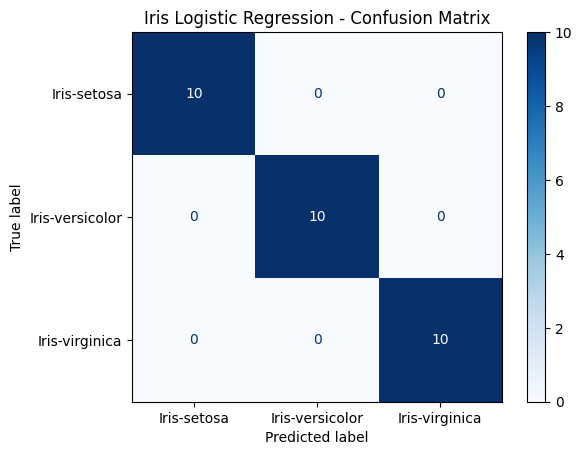

In [11]:
# 6. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    cmap="Blues",
    values_format="d"
)

plt.title("Iris Logistic Regression - Confusion Matrix")
plt.show()